**Заголовок:** 

Модель для поддержания активности постоянных клиетов интернет-магазина «В один клик»

**Цель исследования:** 

Разработать решение, которое позволит персонализировать предложения постоянным клиентам, чтобы увеличить их покупательскую активность

**Ход исследования:**
1. Анализ информации о данных: загрузка и изучение общей информации из датасетов
2. Предобработка данных: обработка дубликатов и изменение типов данных
3. Исследовательский анализ данных: отбор клиентов с покупательской активностью не менее трёх месяцев
4. Объединение таблиц market_file.csv, market_money.csv и market_time.csv
5. Корреляционный анализ признаков в итоговой таблице
6. Использование пайплайнов:выбор лучшей модели
7. Анализ важности признаков
8. Сегментация покупателей: предложения по работе с сегментом для увеличения покупательской активности

**Общий вывод:** резюмирование полученных результатов, формулировка ключевых выводов и рекомендаций

In [1]:
#загружаю библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as st
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, f1_score
from phik import phik_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import shap

## Загрузка данных

In [2]:
#открываю данные
df_market_file = pd.read_csv('/datasets/market_file.csv', sep=',') #данные о поведении покупателя на сайте, о коммуникациях с покупателем и его продуктовом поведении
df_market_money = pd.read_csv('/datasets/market_money.csv', sep=',') #сколько покупатель всего потратил за период взаимодействия с сайтом
df_market_time = pd.read_csv('/datasets/market_time.csv', sep=',') #время (в минутах), которое покупатель провёл на сайте в течение периода
df_money = pd.read_csv('/datasets/money.csv', sep=';', decimal = ',') #среднемесячной прибыли продавца за последние 3 месяца от продаж каждому покупателю

In [3]:
df_market_file.info() #общая информация о данных о поведении покупателя на сайте

In [4]:
df_market_file.head() #вывожу первые строки

In [5]:
df_market_file.describe()

В данных df_market_file 1300 строк. Пропуски отсутствуют. Названия некоторых столбцов содержат пробелы, что нужно будет исправить в дальнейшем

In [6]:
df_market_money.info() #общая информация о том, сколько покупатель всего потратил за период взаимодействия с сайтом

In [7]:
df_market_money.head() #вывожу первые строки

In [8]:
df_market_money.describe()

В данных df_market_money 3900 строк. Пропуски отсутствуют. Вероятно есть выбросы, так как максимальные и минимальные значения сильно отличаются от квартилей, вдальнейшем построю графики и разбирусь с этим

In [9]:
df_market_time.info() #общая информация о времени (в минутах), которое покупатель провёл на сайте в течение периода

In [10]:
df_market_time.head() #вывожу первые строки

In [11]:
df_market_time.describe()

В данных df_market_time 2600 строк. Пропуски отсутствуют. В периоде есть опечатки, нужно будет исправить

In [12]:
df_money.info() #общая информация о среднемесячной прибыли продавца за последние 3 месяца от продаж каждому покупателю

In [13]:
df_money.head() #вывожу первые строки

In [14]:
df_money.describe()

В данных df_market_time 1300 строк. Пропуски отсутствуют

**Выводы:** 
1. В данных df_market_file 1300 строк. Пропуски отсутствуют. Названия некоторых столбцов содержат пробелы, что нужно будет исправить в дальнейшем
2. В данных df_market_money 3900 строк. Пропуски отсутствуют. Вероятно есть выбросы, так как максимальные и минимальные значения сильно отличаются от квартилей
3. В данных df_market_time 2600 строк. Пропуски отсутствуют. В периоде есть опечатки, нужно будет исправить
4. В данных df_market_time 1300 строк. Пропуски отсутствуют

##  Предобработка данных

**Переименование столбцов**

В описании проекта сказано, что названия столбцов можно оставить кириллическими, поэтому заменим пробелы на подчеркивания и приведем к нижнему регистру

In [15]:
def columns_remove_spaces(df):
    df.columns = df.columns.str.replace(' ', '_').str.lower()

In [16]:
columns_remove_spaces(df_market_file)
columns_remove_spaces(df_market_money)
columns_remove_spaces(df_market_time)
columns_remove_spaces(df_money)

In [17]:
print(df_market_file.columns)
print(df_market_money.columns)
print(df_market_time.columns)
print(df_money.columns)

**Поиск дубликатов**

In [18]:
#исследую данные на наличие явных дубликатов
print('Количество явных дубликатов в "df_market_file" = ', df_market_file.duplicated().sum())
print('Количество явных дубликатов в "df_market_money" = ', df_market_money.duplicated().sum())
print('Количество явных дубликатов в "df_market_time" = ', df_market_time.duplicated().sum())
print('Количество явных дубликатов в "df_money" = ', df_money.duplicated().sum())

In [19]:
df_market_file[df_market_file.duplicated(subset=['покупательская_активность', 'тип_сервиса', 'разрешить_сообщать',
       'маркет_актив_6_мес', 'маркет_актив_тек_мес', 'длительность',
       'акционные_покупки', 'популярная_категория',
       'средний_просмотр_категорий_за_визит',
       'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса',
       'страниц_за_визит'])]

Если исключить id, то обнаруживается 11 дубликатов. Не считаю целесообразным их удалять

Явных дубликатов не обнаружено

**Анализ уникальных наименований**

In [20]:
print(f'Уникальные значения для покупательской активности:{df_market_file["покупательская_активность"].unique()}')
print(f'Уникальные значения для типа сервиса:{df_market_file["тип_сервиса"].unique()}')
print(f'Уникальные значения для разрешения сообщений:{df_market_file["разрешить_сообщать"].unique()}')
print(f'Уникальные значения для популярной категории:{df_market_file["популярная_категория"].unique()}')
print(f'Уникальные значения для периода:{df_market_money["период"].unique()}, {df_market_time["период"].unique()}')

In [21]:
#привожу значения к единообразию
df_market_file["тип_сервиса"] = df_market_file["тип_сервиса"].replace({'стандартт': 'стандарт'})
df_market_time["период"] = df_market_time["период"].replace({'предыдцщий_месяц': 'предыдущий_месяц'})
df_market_file["популярная_категория"] = df_market_file["популярная_категория"].replace({'Косметика и аксесуары': 'Косметика и аксессуары'})
#проверяю изменения
print(f'Уникальные значения для типа сервиса:{df_market_file["тип_сервиса"].unique()}')
print(f'Уникальные значения для периода:{df_market_time["период"].unique()}')
print(f'Уникальные значения для популярной категории:{df_market_file["популярная_категория"].unique()}')

**Выводы:**

В ходе предобработки данных в датафреймах сделаны следующие преобразования:
1. Названия столбцов во всех датасетах приведены к единому формату
2. В столбцах тип_сервиса и период значения приведены к единому образцу

##  Исследовательский анализ данных

**Статистический анализ признаков**

In [22]:
def plot_numeric_features(df):
    for column in df.columns:
        if column != 'id':
            # проверяю, является ли признак дискретным или непрерывным
            if pd.api.types.is_integer_dtype(df[column]) or pd.api.types.is_categorical_dtype(df[column]):
                # столбчатая диаграмма для дискретных признаков
                plt.figure(figsize=(8, 4))
                sns.countplot(x=df[column], color='blue')
                plt.title(f'Столбчатая диаграмма {column}')
                plt.xlabel(column)
                plt.ylabel('Частота')
                plt.grid(axis='y', alpha=0.75)
                plt.show()
            elif pd.api.types.is_numeric_dtype(df[column]):
                # ДЛЯ КОЛИЧЕСТВЕННЫХ ПРИЗНАКОВ: строим И гистограмму, И boxplot
                fig, axes = plt.subplots(1, 2, figsize=(14, 4))
                
                # Гистограмма
                axes[0].hist(df[column], bins=20, alpha=0.7, color='blue', edgecolor='black')
                axes[0].set_title(f'Гистограмма {column}')
                axes[0].set_xlabel(column)
                axes[0].set_ylabel('Частота')
                axes[0].grid(axis='y', alpha=0.75)
                
                # Boxplot (ящик с усами)
                axes[1].boxplot(df[column])
                axes[1].set_title(f'Ящик с усами {column}')
                axes[1].set_ylabel(column)
                axes[1].grid(axis='y', alpha=0.75)
                
                plt.tight_layout()
                plt.show()


In [23]:
#создаю функцию для визуализации категориальных признаков
def plot_categorical_features(df):
    for column in df.columns:
        plt.figure(figsize=(14, 6))  # Размер фигуры увеличен для лучшего представления графиков

        if pd.api.types.is_categorical_dtype(df[column]) or pd.api.types.is_object_dtype(df[column]):
            category_counts = df[column].value_counts()

            # Столбчатая диаграмма
            plt.subplot(1, 2, 1)
            category_counts.plot(kind='bar', alpha=0.7, color='orange')
            plt.title(f'Частота категорий в {column}')
            plt.xlabel(column)
            plt.ylabel('Количество')
            plt.xticks(rotation=45, ha='right')  # Поворот и выравнивание меток по оси x
            plt.grid(axis='y', alpha=0.75)

            # Круговая диаграмма с процентами
            plt.subplot(1, 2, 2)
            plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=90,
                    colors=plt.cm.tab20.colors, textprops={'fontsize': 10})  # Увеличение шрифта текста
            plt.title(f'Распределение {column} (круговая диаграмма)')
            plt.axis('equal')

            plt.tight_layout()  # Регулировка отступов между подграфиками
            plt.show()

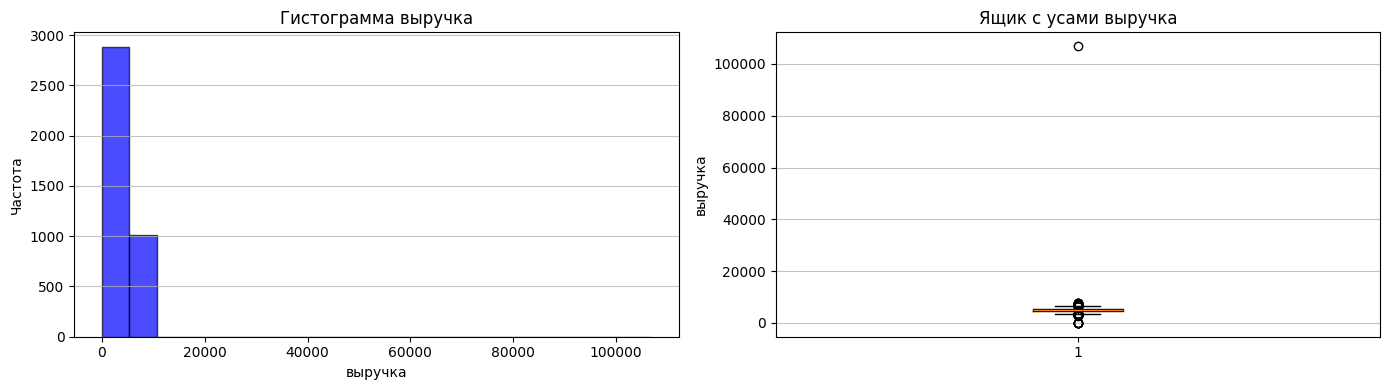

In [24]:
# визуализирую количественные признаки df_market_money
plot_numeric_features(df_market_money)

Есть выброс. Заменяю его на медианное значение

In [25]:
median_value = df_market_money['выручка'].median()

# заменяю выброс
df_market_money['выручка'] = df_market_money['выручка'].apply(
    lambda x: median_value if x > 10000 else x
)

df_market_money['выручка'].describe()

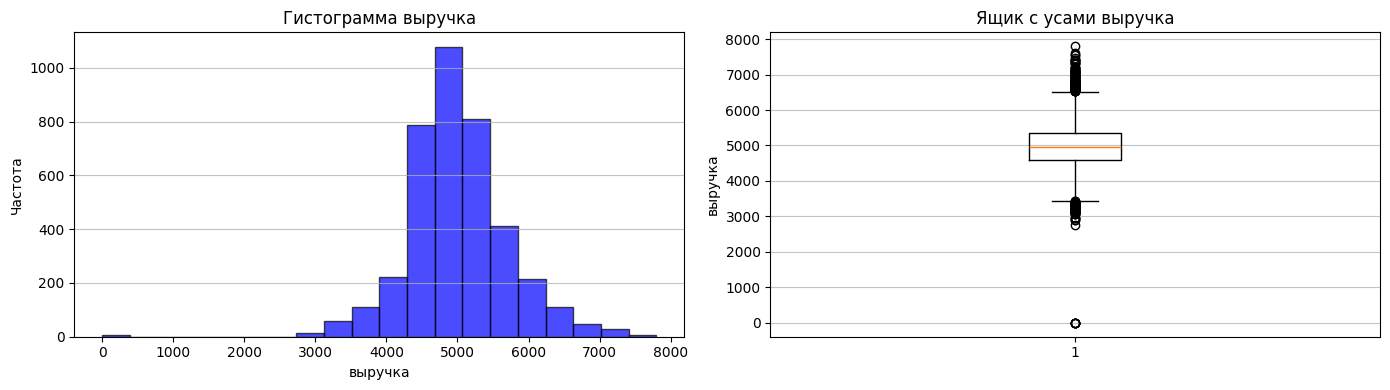

In [26]:
plot_numeric_features(df_market_money)

Видно, что не все покупатели были активны в течение последних трех месяцев. Отберем клиентов с покупательской активностью не менее трёх месяцев, то есть таких, которые что-либо покупали в этот период.

In [27]:
values = df_market_money[df_market_money['выручка'] == 0]['id'].unique()
df_market_money_aktiv = df_market_money[df_market_money['id'].isin(values) == False ]
money_small = df_market_money[df_market_money['выручка'] == 0]['id'].nunique()
money_big = df_market_money_aktiv['id'].nunique()
print(f'Общее количество клиентов - ', df_market_money['id'].nunique())
print(f'Количество клиентов с активностью не менее трех месяцев -', df_market_money_aktiv['id'].nunique())

Далее в исследовании будем работать с этими клиентами.

In [28]:
df_market_file = df_market_file[df_market_file['id'].isin(values) == False ]
print(f'Общее количество активных клиентов - ', df_market_file['id'].nunique())

df_market_money = df_market_money_aktiv
print(f'Общее количество активных клиентов - ', df_market_money['id'].nunique())

df_market_time = df_market_time[df_market_time['id'].isin(values) == False ]
print(f'Общее количество активных клиентов - ', df_market_time['id'].nunique())

df_money = df_money[df_money['id'].isin(values) == False ]
print(f'Общее количество активных клиентов - ', df_money['id'].nunique())

In [29]:
# визуализирую категориальные признаки df_market_money
plot_categorical_features(df_market_money)

In [30]:
display(df_market_money.pivot_table(index='период', values=['выручка'], aggfunc='sum'))

Выручка за последние три месяца примерно одинаковая

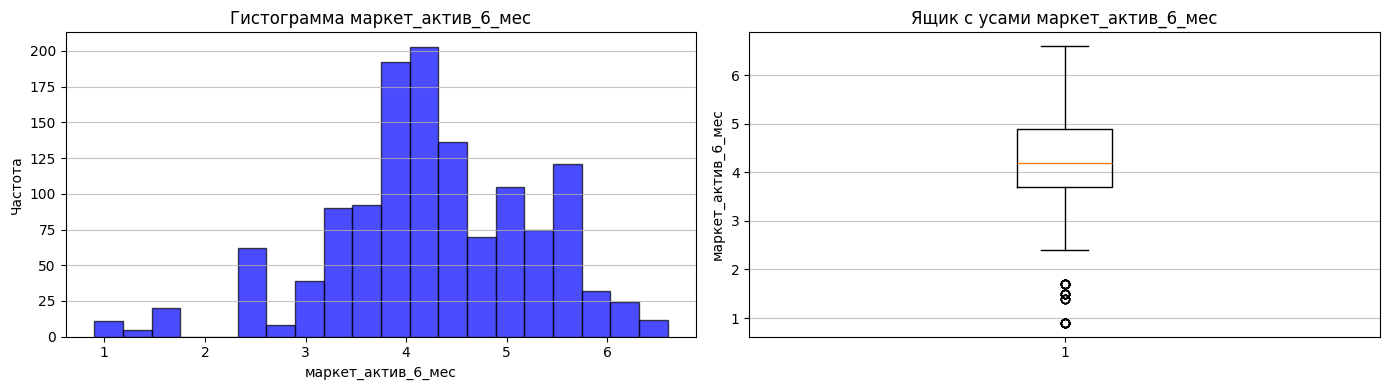

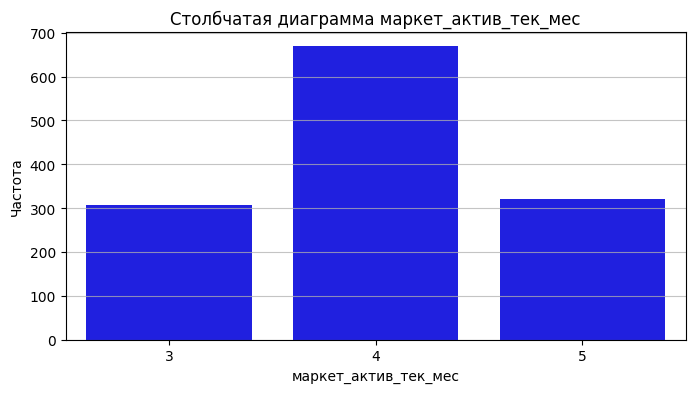

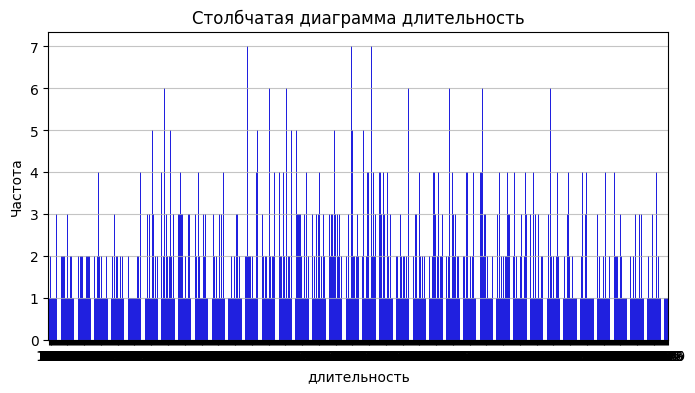

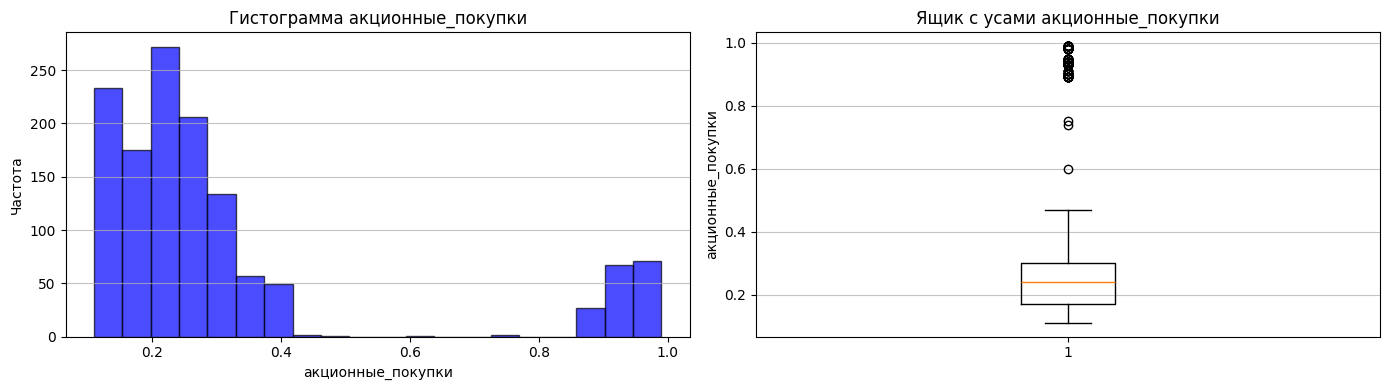

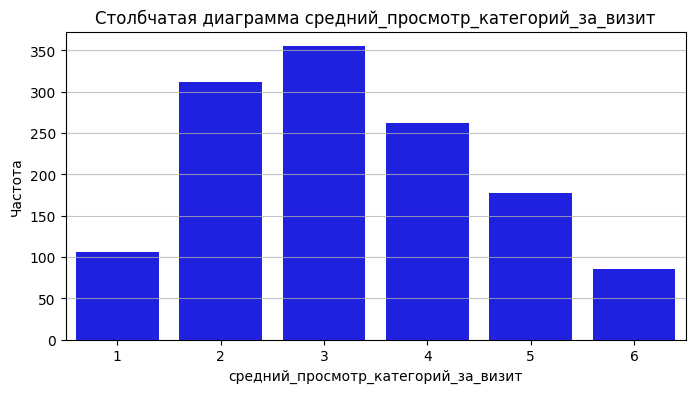

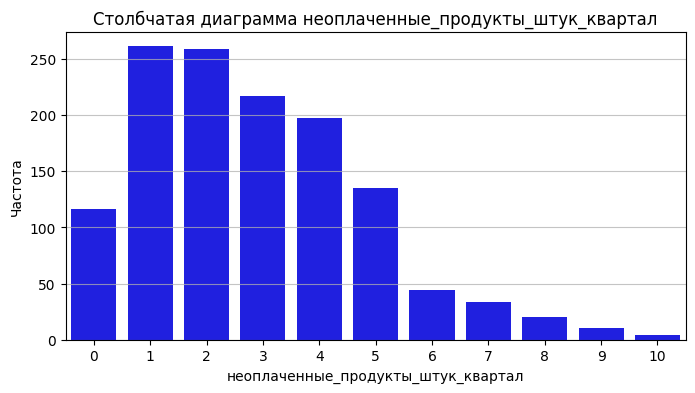

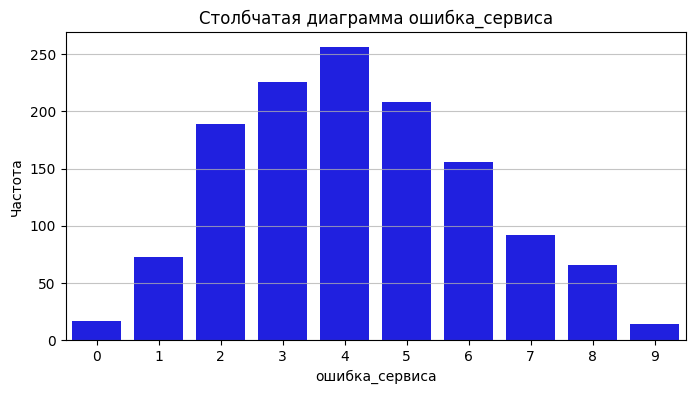

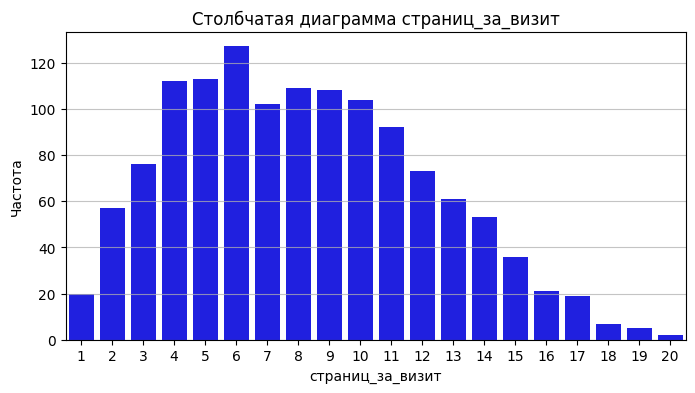

In [31]:
# визуализирую количественные признаки df_market_file
plot_numeric_features(df_market_file)

Большинство покупателей не ориентируются на скидки. Но часть клиентов отлеживают скидки. Поэтому подготовке данных для модели нужно превратить колонку акционные_покупки в категоральный признак.
Возможно, стоит поработать над стабильностью работы сайта. В среднем 4 разаза визит возникает ошибка сервиса.

In [32]:
# визуализирую категориальные признаки df_market_file
plot_categorical_features(df_market_file)

<div class="alert alert-warning">
<b>Комментарий 👉</b>

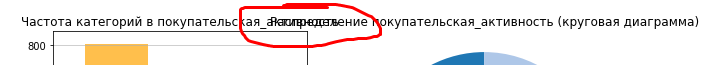
</div>

Видно дисбаланс значений в целевом признаке, это нужно будет учесть в модели
Большинство клиентов (71,1%) пользуются типом сервиса стандарт
Самымой популярной категорией являются товары для детей, наименее популярной - кухонная посуда

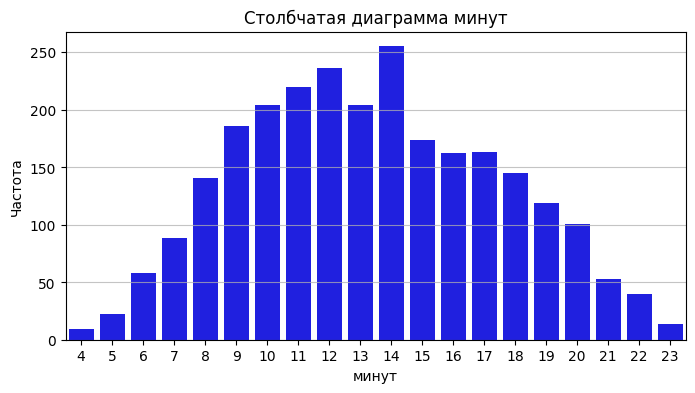

In [33]:
# визуализирую количественные признаки df_market_time
plot_numeric_features(df_market_time)

Половина покупателей проводят на сайте от 10 до 16 минут.

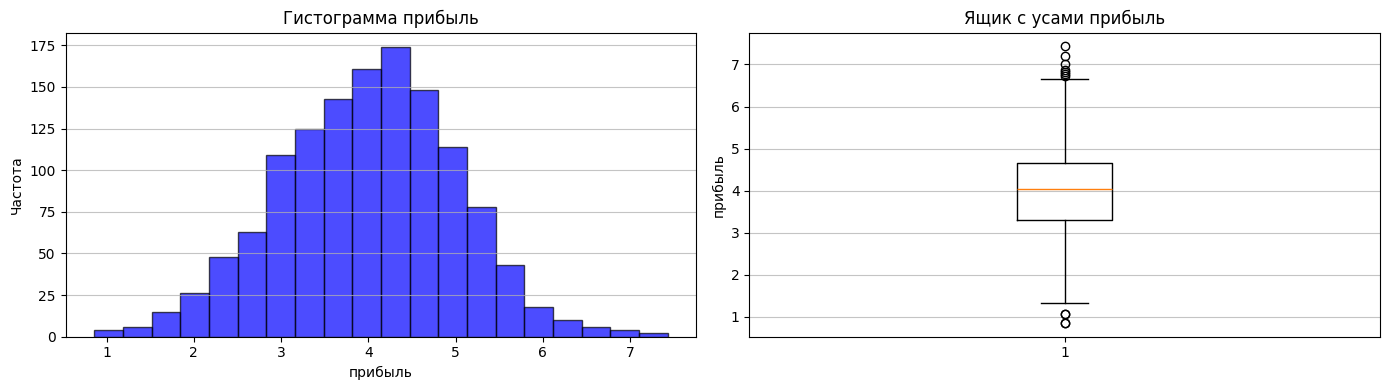

In [34]:
# визуализирую количественные признаки df_money
plot_numeric_features(df_money)

**Выводы:**
1. В df_market_money один выброс был заменен на медианное занчение.
2. Трое из 1300 покупателей не были активны в течение трех месяцев. Поэтому данные по ним исключены из анализа.
3. Выручка за последние три месяца примерно одинаковая
4. Большинство покупателей не ориентируются на скидки. Но часть клиентов отлеживают скидки. Поэтому подготовке данных для модели нужно превратить колонку акционные_покупки в категоральный признак.
5. Возможно, стоит поработать над стабильностью работы сайта. В среднем 4 разаза визит возникает ошибка сервиса.
6. Видно дисбаланс значений в целевом признаке, это нужно будет учесть в модели
7. Большинство клиентов (71,1%) пользуются типом сервиса стандарт
8. Самымой популярной категорией являются товары для детей, наименее популярной - кухонная посуда
9. Половина покупателей проводят на сайте от 10 до 16 минут.

## Объединение таблиц

Объединяю данные из датафреймов df_market_file, df_market_money, df_market_time в одну таблицу

In [35]:
df_market_money.head()

In [36]:
# df_market_money['выручка_текущий_месяц'] = df_market_money.loc[df_market_money['период'] == 'текущий_месяц', 'выручка']
# df_market_money['выручка_предыдущий_месяц'] = df_market_money.loc[df_market_money['период'] == 'предыдущий_месяц', 'выручка']   
# df_market_money['выручка_препредыдущий_месяц'] = df_market_money.loc[df_market_money['период'] == 'препредыдущий_месяц', 'выручка']   
# drop_columns=['период', 'выручка']
# df_market_money= df_market_money.drop(drop_columns, axis =1)
# df_market_money = df_market_money.groupby('id') .agg ({'выручка_текущий_месяц':'first', 'выручка_предыдущий_месяц':'first',
#                                                  'выручка_препредыдущий_месяц':'first' })
# df_market_money.head()

In [37]:
# извлекаю выручку для текущего, предыдущего и препредыдущего месяцев,
# фильтруя данные по соответствующему 'периоду'
df_market_money['выручка_текущий_месяц'] = df_market_money.loc[
    df_market_money['период'] == 'текущий_месяц', 'выручка'
]

df_market_money['выручка_предыдущий_месяц'] = df_market_money.loc[
    df_market_money['период'] == 'предыдущий_месяц', 'выручка'
]

df_market_money['выручка_препредыдущий_месяц'] = df_market_money.loc[
    df_market_money['период'] == 'препредыдущий_месяц', 'выручка'
]

# удаляю ненужные колонки ('период' и 'выручка')
drop_columns = ['период', 'выручка']
df_market_money = df_market_money.drop(drop_columns, axis=1)

# группирую данные по 'id' и агрегирую выручку по месяцам,
# выбирая первую (единственную) запись для каждого 'id'
df_market_money = df_market_money.groupby('id').agg({
    'выручка_текущий_месяц': 'first',
    'выручка_предыдущий_месяц': 'first',
    'выручка_препредыдущий_месяц': 'first'
})

df_market_money.head()

In [38]:
df_market_time['период_текущий_месяц'] = df_market_time.loc[df_market_time['период'] == 'текущий_месяц', 'минут']
df_market_time['период_предыдущий_месяц'] = df_market_time.loc[df_market_time['период'] == 'предыдущий_месяц', 'минут']
drop_columns=['период', 'минут']
df_market_time= df_market_time.drop(drop_columns, axis =1)
df_market_time = df_market_time.groupby('id') .agg ({'период_текущий_месяц':'first', 'период_предыдущий_месяц':'first'})

df_market_time.head()

In [39]:
data = pd.merge(pd.merge(df_market_file, df_market_money, on='id'), df_market_time, on='id')
data = data.set_index('id')
display(data.head())

In [40]:
data.shape

**Выводы:**

После объединения таблиц все данные находятся в одном датасете

## Корреляционный анализ

Провожу корреляционный анализ признаков в количественной шкале в итоговой таблице для моделирования

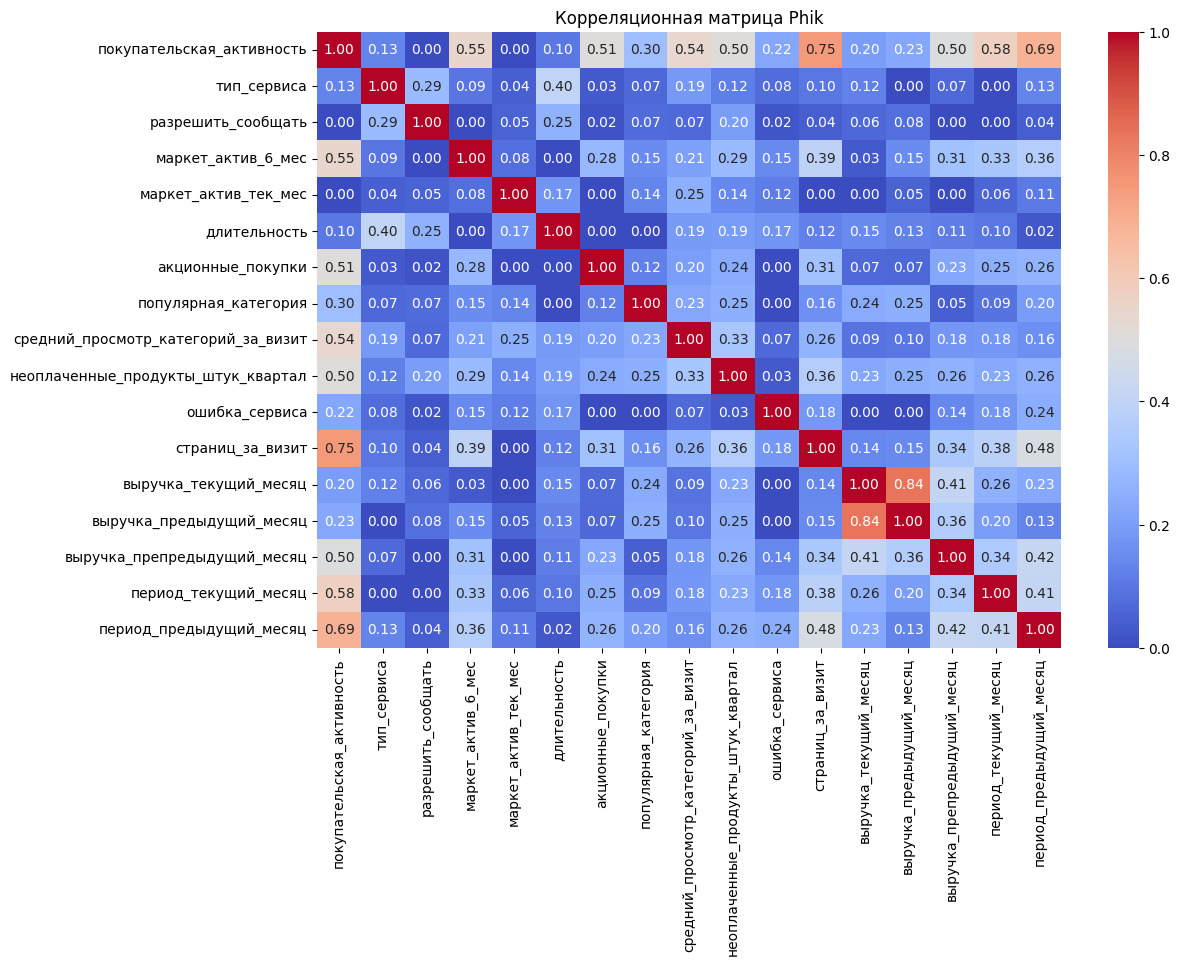

In [41]:
interval_columns = [
    'маркет_актив_6_мес', 
    'маркет_актив_тек_мес', 
    'длительность', 
    'акционные_покупки', 
    'средний_просмотр_категорий_за_визит', 
    'неоплаченные_продукты_штук_квартал', 
    'ошибка_сервиса', 
    'страниц_за_визит', 
    'выручка_текущий_месяц', 
    'выручка_предыдущий_месяц', 
    'выручка_препредыдущий_месяц', 
    'период_текущий_месяц', 
    'период_предыдущий_месяц'
]

# вычисление матрицы корреляции с методом Phik
phik_matrix_result = data.phik_matrix(interval_cols=interval_columns)

# визуализация
plt.figure(figsize=(12, 8))
sns.heatmap(phik_matrix_result, annot=True, fmt='.2f', cmap='coolwarm', annot_kws={"size": 10})
plt.title('Корреляционная матрица Phik')
plt.show()

Целевой признак, связанный с покупательской активностью, имеет корреляцию с количеством страниц, которые клиенты просматривают за один визит, а также с временем, проведённым в предыдущем и текущем месяце. Из всех признаков наблюдается лишь одна относительно сильная корреляция между выручкой за предыдущий месяц и текущим месяцем, однако коэффициент корреляции составляет менее 0.9, что означает, что нет необходимости удалять эти признаки.

## Использование пайплайнов

Приступаю к построению модели. Переберу модели KNeighborsClassifier(), DecisionTreeClassifier(), LogisticRegression() и SVC(), используя пайплайны.

Подготовлю данные. Закодирую целевой признак в значение 0 и 1. Колонку Акционные_покупки превращаю в категоральный признак. id сделаю индексами

In [42]:
# data['покупательская_активность'] = data['покупательская_активность'].apply( lambda x: 1 if x=='Снизилась' else 0 )
# data['покупательская_активность'] = data['покупательская_активность'].astype(int)

In [43]:
# cоздаю экземпляр LabelEncoder
le = LabelEncoder()

# кодирую целевой признак
data['покупательская_активность'] = le.fit_transform(data['покупательская_активность'])

# меняю метки местами
inverted_target = 1 - data['покупательская_активность']

print("Измененные классы целевой переменной:", inverted_target.values)

In [44]:
data['акционные_покупки'] = data['акционные_покупки'].apply( lambda x: 'часто покупает по акции' if x>= 0.5 else 'редко покупает по акции' )

In [45]:
display(data.head())

Проверяю наличие дисбаланса классов

In [46]:
data['покупательская_активность'].value_counts(normalize=True)

Нужно провести стратификацию данных при их подготовке

In [47]:
RANDOM_STATE=42

X = data.drop(['покупательская_активность'], axis=1)
y = data['покупательская_активность']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.25, 
    random_state = RANDOM_STATE,
    stratify = y)

In [48]:
print("Размерности выборок:")
print("Тренировочная выборка (X_train):", X_train.shape)
print("Тестовая выборка (X_test):", X_test.shape)

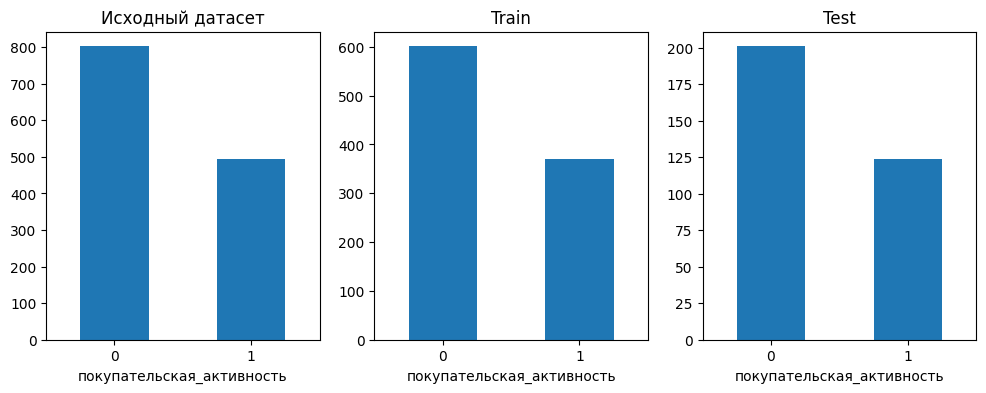

In [49]:
# визуализация баланса целевого признака в выборках
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

y.value_counts().plot(kind='bar', ax=ax[0], rot=0)
ax[0].set_title("Исходный датасет")
y_train.value_counts().plot(kind='bar', ax=ax[1], rot=0)
ax[1].set_title("Train")
y_test.value_counts().plot(kind='bar', ax=ax[2], rot=0)
ax[2].set_title("Test")

plt.show()

Начинаю собирать пайплайн:

In [50]:
ohe_columns = ['разрешить_сообщать', 'популярная_категория', 'тип_сервиса']
ord_columns = ['акционные_покупки']
num_columns = ['маркет_актив_6_мес', 'маркет_актив_тек_мес', 'маркет_актив_тек_мес', 
               'длительность', 'средний_просмотр_категорий_за_визит',
               'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса', 'страниц_за_визит', 'выручка_текущий_месяц',
               'выручка_предыдущий_месяц', 'выручка_препредыдущий_месяц', 'период_текущий_месяц', 
               'период_предыдущий_месяц']

In [51]:
ohe_pipe = Pipeline(
    [
        ('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
    ]
)

In [52]:
# cоздаю пайплайн для подготовки признаков из списка ord_columns
ord_pipe = Pipeline(
    [
        (
            'simple_imputer_ord_before',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ord',
            OrdinalEncoder(categories=[
                                      ['редко покупает по акции','часто покупает по акции']],
                          handle_unknown='use_encoded_value',
                          unknown_value=np.nan)
        ),
        (
            'simple_imputer_ord_after',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        )
    ]
)

In [53]:
# создаю общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)

Объединила этапы подготовки данных, применяя пайплайны ohe_pipe и ord_pipe. Данные в числовых столбцах, обозначенных как num_columns, а также в столбцах minmax_columns подверглись масштабированию. В соответствии с условиями задачи использовала два кодировщика и два скейлера.

In [54]:
# создаю итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

In [55]:
param_grid = [
    # словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 7),
        'models__max_features': range(2,7),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    
    # словарь для модели KNeighborsClassifier() 
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2,5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    },

    # словарь для модели LogisticRegression()
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            penalty='l1'
        )],
        'models__C': range(1,5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    # словарь для модели SVC()
    {
        'models': [SVC(random_state=RANDOM_STATE, kernel='poly')],
        'models__degree': range(2, 3),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    }
,
    # RandomForestClassifier
    {
        "models": [RandomForestClassifier()],
        "models__n_estimators": [50, 100, 200],
        "models__max_depth": [None, 5, 10, 15],
        "models__min_samples_split": [2, 5, 10],
        "models__random_state": [42]
    }
]

Наиболее подходящей метрикой для нашей задачи является roc-auc. Она демонстрирует связь между истинно положительными (TPR) и ложными положительными (FPR) наблюдениями, благодаря чему всегда предоставляет адекватную оценку качества модели. В отличие от этого, метрика F1 может указывать на низкое качество, если хотя бы одна из её составляющих показывает плохие результаты. Что касается accuracy, эта метрика учитывает лишь общее количество правильных предсказаний, не обращая внимания на то, как модель работает с минорными классами. Поэтому использовать её в условиях дисбаланса классов нецелесообразно

In [56]:
randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    cv=10,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
randomized_search.fit(X_train, y_train) 

In [57]:
print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)
print ('Метрика лучшей модели на тренировочной выборке:', round(randomized_search.best_score_, 2))

### Проверка: что возвращает predict_proba()[:,1]?

Важно убедиться, что `.predict_proba()[:,1]` возвращает вероятность именно класса "Снизилась", а не "Не снизилась". Проверим это:

In [72]:
# Проверяем соответствие между классами и индексами в predict_proba
print("Классы модели:", randomized_search.classes_)
print("\nИндекс 0 соответствует классу:", randomized_search.classes_[0])
print("Индекс 1 соответствует классу:", randomized_search.classes_[1])

# Получаем вероятности для первых 5 наблюдений тестовой выборки
sample_probas = randomized_search.predict_proba(X_test)[:5]
sample_preds = randomized_search.predict(X_test)[:5]
sample_actual = y_test.values[:5]

print("\n" + "="*70)
print("Пример предсказаний на тестовой выборке:")
print("="*70)
for i in range(5):
    print(f"\nНаблюдение {i+1}:")
    print(f"  Фактическое значение: {sample_actual[i]}")
    print(f"  Вероятность '{randomized_search.classes_[0]}': {sample_probas[i][0]:.4f}")
    print(f"  Вероятность '{randomized_search.classes_[1]}': {sample_probas[i][1]:.4f}")
    print(f"  Предсказанный класс: {sample_preds[i]}")


Вывод: под единицей закодирован целевой класс

In [59]:
y_test_pred = randomized_search.predict(X_test)
y_test_proba = randomized_search.predict_proba(X_test)
print(f'Метрика ROC-AUC на тестовой выборке: {round(roc_auc_score(y_test, y_test_proba[:,1]), 2)}')

**Выводы:**

В результате анализа различных моделей с использованием пайплайнов наилучшей моделью оказалась линейная регрессия. Она обладает следующими характеристиками: значение параметра C равно 4, что указывает на умеренную регуляризацию — высокий параметр C позволяет модели лучше адаптироваться к данным, что в данном случае свидетельствует о относительно слабой регуляризации. Параметр penalty установлен на 'l1', что подразумевает использование L1-регуляризации, которая добавляет штраф за абсолютные значения коэффициентов модели во время процесса обучения. Это способствует отбору значимых признаков, приводя к тому, что менее важные параметры могут быть обнулены. Также фиксирован параметр random_state равным 42, что служит простой константой для обеспечения воспроизводимости результатов. Алгоритм оптимизации выбранный для обучения модели — 'liblinear', который хорошо подходит для задач двоичной классификации и эффективно справляется с средними и крупными наборами данных. Значение ROC AUC составило 0.92, что демонстрирует достаточно высокий уровень точности модели.

## Анализ важности признаков

Строю график общей значимости признаков:

In [60]:
X_train_2 = pipe_final.named_steps['preprocessor'].fit_transform(X_train)
X_test_2 = pipe_final.named_steps['preprocessor'].transform(X_test)
feature_names = pipe_final.named_steps['preprocessor'].get_feature_names_out()
X_test_2 = pd.DataFrame(X_test_2, columns=feature_names)
explainer = shap.LinearExplainer(randomized_search.best_estimator_.named_steps['models'], X_train_2)
shap_values = explainer(X_test_2)

Строю график общей значимости признаков:

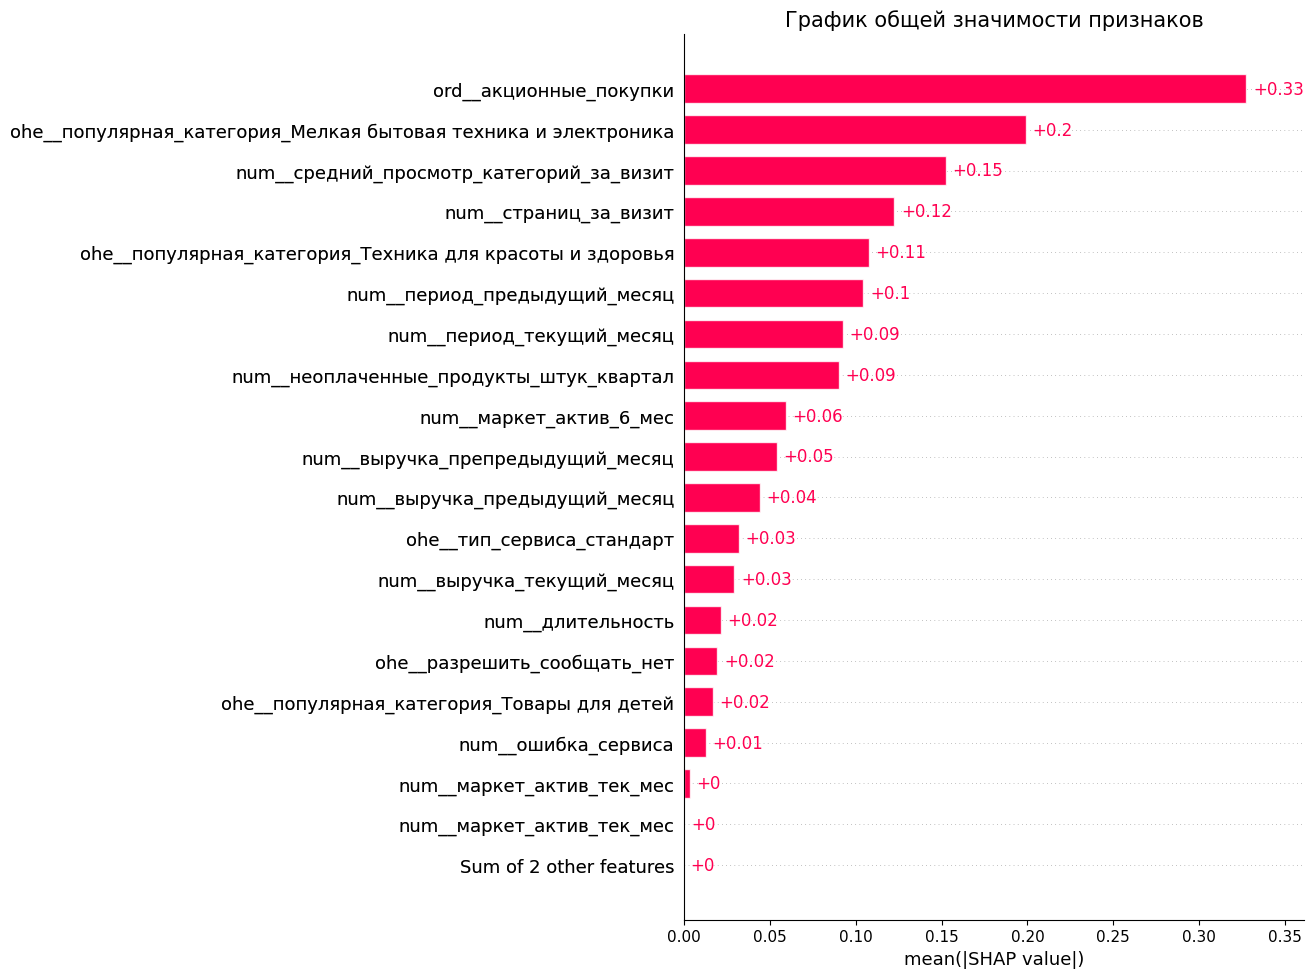

In [61]:
shap.plots.bar(shap_values, max_display=20, show=False)
plt.title('График общей значимости признаков', size=15)
plt.show()

Самыми важными признаками для построения модели были:

- акционные покупки;
- популярная категория;
- средний просмотр категорий за визит;
- страниц за визит;
- проведенное в прошлом месяце время.

Как признаки влияют на каждое предсказание модели:

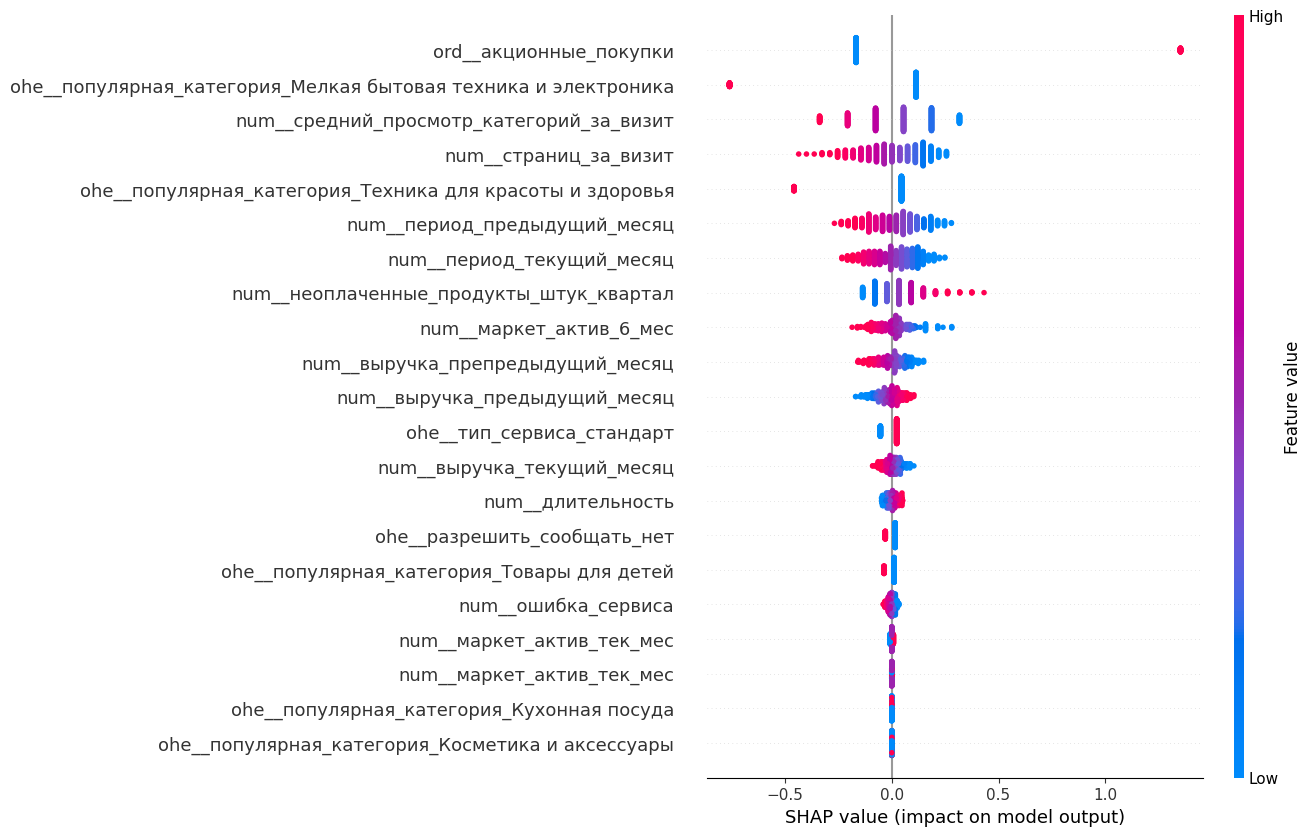

In [62]:
shap.plots.beeswarm(shap_values, max_display=25)

**Выводы:**

Для итоговой модели которую мы отобрали наиболее важными признаками является:
- доля акционных покупок;
- среднее кол-во просмотренных категорий за визит;
- проведенное в предыдущем и в этом месяце время;
- кол-во неоплаченных товаров в корзине за квартал.

Наименее важны оказались следующие признаки:
- выручка за текущий и предыдущий месяцы;
- популярные категории (за исключением бытовой техники и техники для красоты;
- разрешение на отправку рекламынх рассылок;
- тип сервиса;
- ошибки сервиса;
- длительность.

При принятии бизнес-решений важно учитывать поведение клиентов на сайте. Следует сосредоточиться на увеличении их вовлеченности, что включает в себя изучение времени прокрутки страниц и эффективность презентации новых категорий товаров. Организация скидок также может способствовать повышению интереса и активности пользователей.

## Сегментация покупателей

In [63]:
y_test_proba = randomized_search.predict_proba(X_test)[:,1]
y_train_proba = randomized_search.predict_proba(X_train)[:,1]
X_test.head(3)

In [64]:
df_money.head()

In [65]:
X_test_full = X_test.copy()
X_train_full = X_train.copy()
X_test_full['вероятность_снижения'] = y_test_proba
X_train_full['вероятность_снижения'] = y_train_proba
df_full = pd.concat([X_train_full, X_test_full])

df_money = df_money.set_index('id')
df_full = df_full.join(df_money)
df_full.head(5)

Анализирую характеристики взаимодействия с клиентом

In [66]:
def customer_activity(data, x, columns):  
    for col in columns:
        plt.figure(figsize=(10, 6))  # Устанавливаем размеры графика
        sns.relplot(data=data, x=x, y='вероятность_снижения', hue=col)
        plt.title(f'Зависимость покупательской активности от {x}, в зависимости от {col}')
        plt.xlabel(x)
        plt.ylabel('Вероятность снижения')
        plt.show()



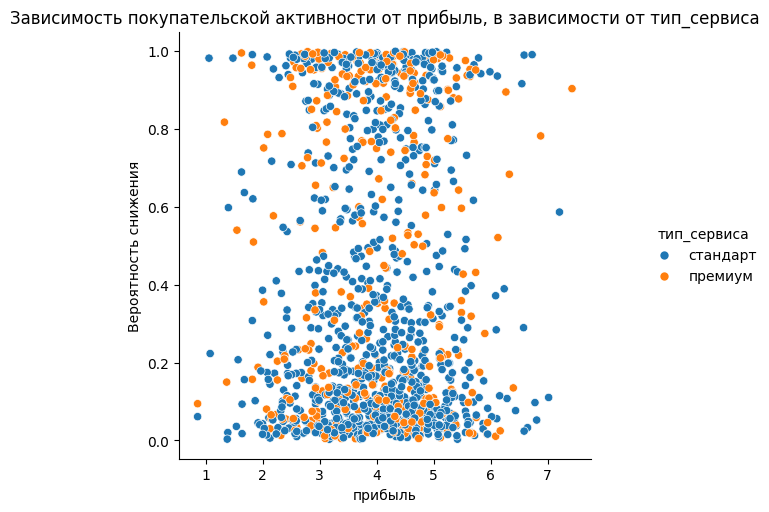

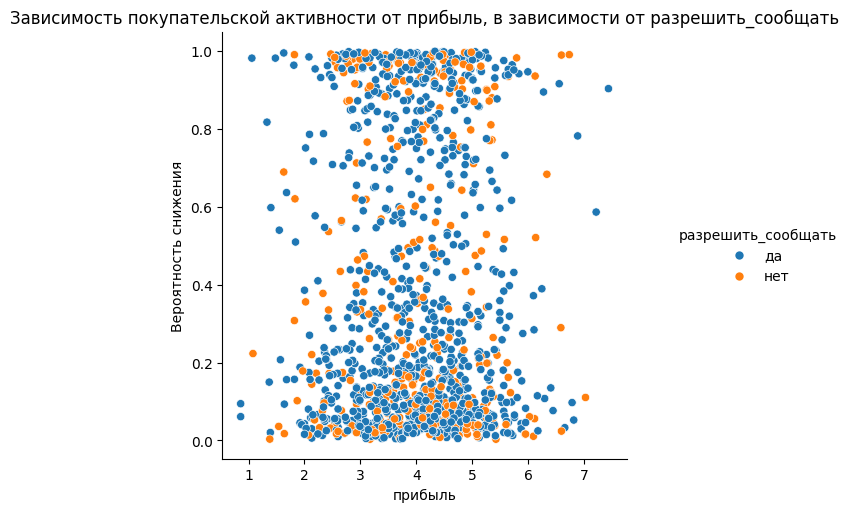

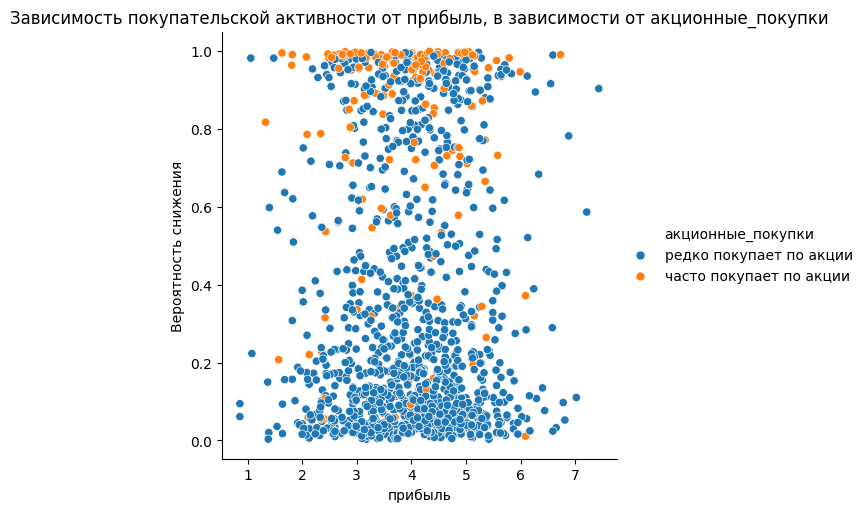

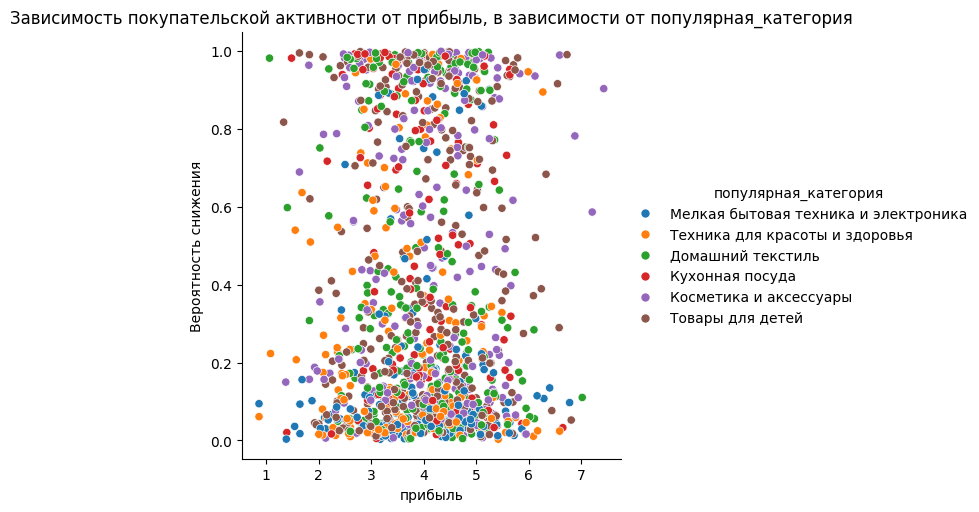

In [67]:
cat_columns = list(df_full.select_dtypes(include='object').columns)
customer_activity(df_full, 'прибыль', cat_columns)

Пользователи, которые часто покупают по скидке чаще всего имеют высокую вероятность снижения активности. Буду исследовать эту группу

In [68]:
# cоздаю новый столбец 'сегмент'
df_full['сегмент'] = 'Остальные пользователи'

# устанавливаем условия для 'Исследуемый сегмент'
df_full.loc[
    (df_full['вероятность_снижения'] > 0.8) & 
    (df_full['акционные_покупки'] == 'часто покупает по акции'), 
    'сегмент'
] = 'Исследуемый сегмент'
display(df_full.tail(5))

In [69]:
def histogram(df, col, target):
    plt.figure(figsize=(8,6))
    plot = sns.histplot(df, bins=20, hue=target, x=col)
    plot.set_title(f'Рапределение по {col}', fontsize=16)
    plot.set_ylabel('Количество', fontsize=14)
    

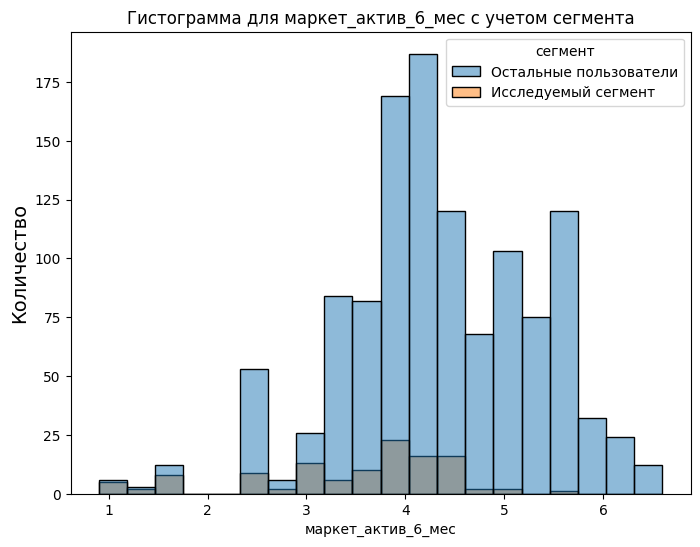

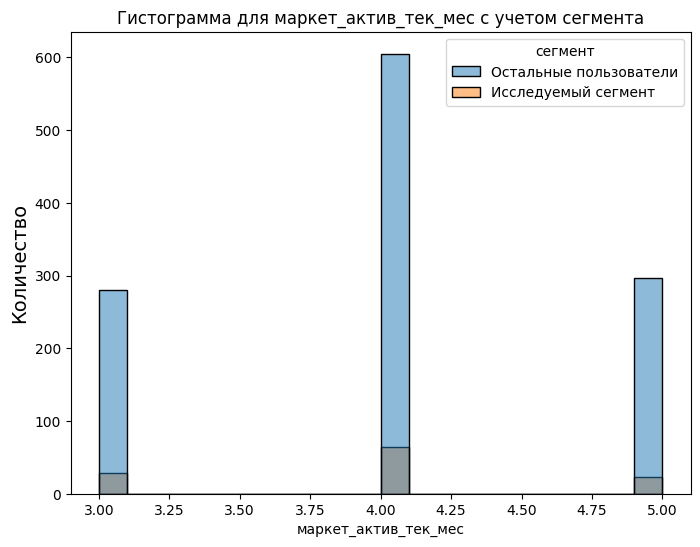

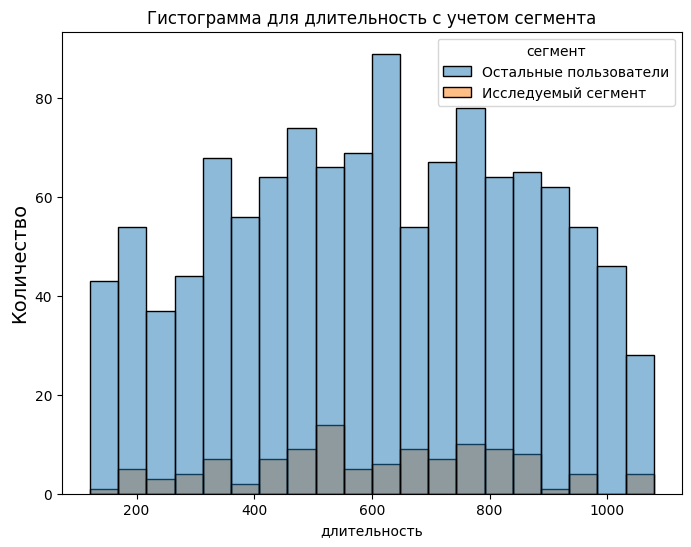

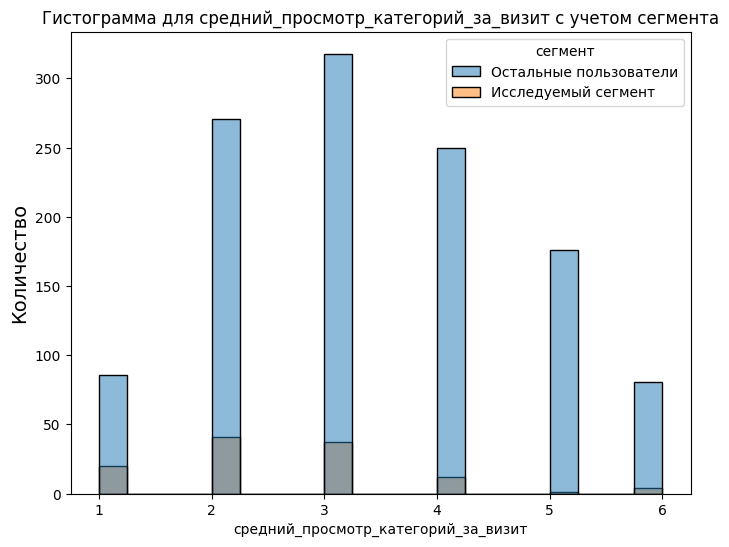

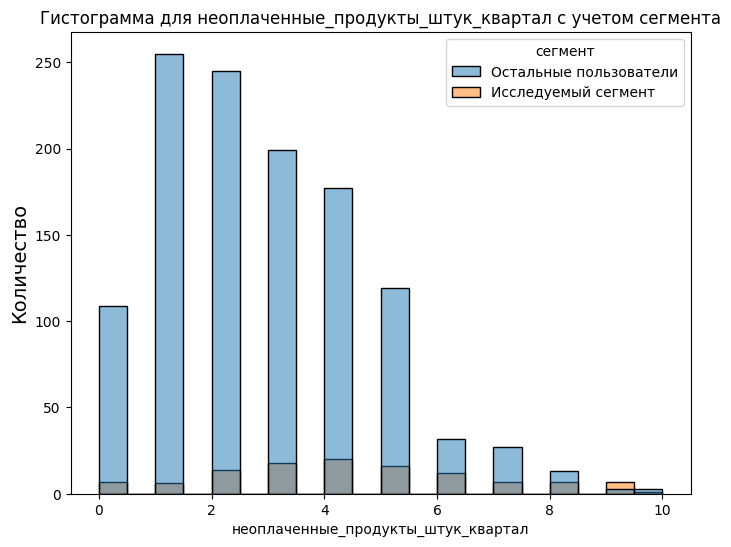

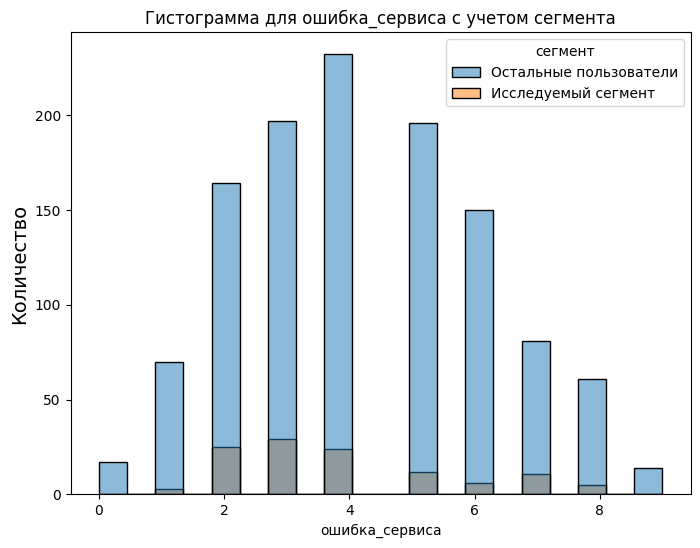

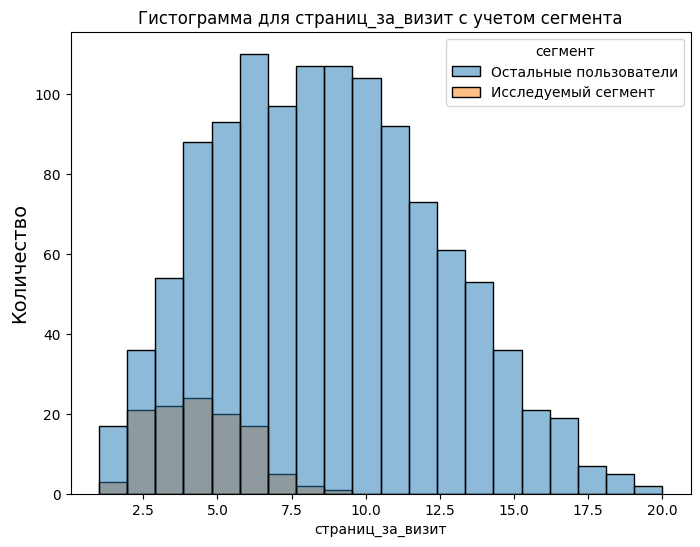

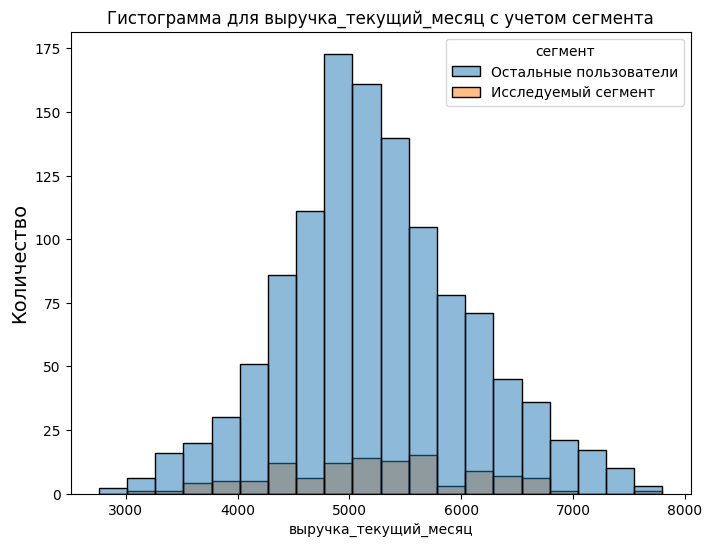

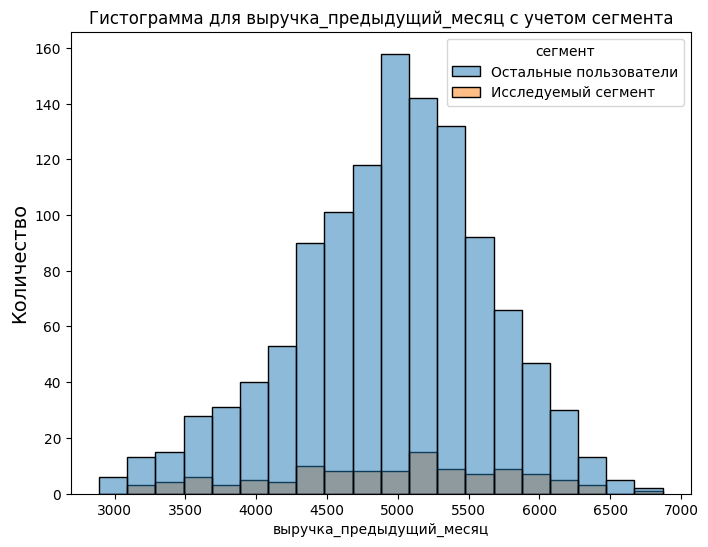

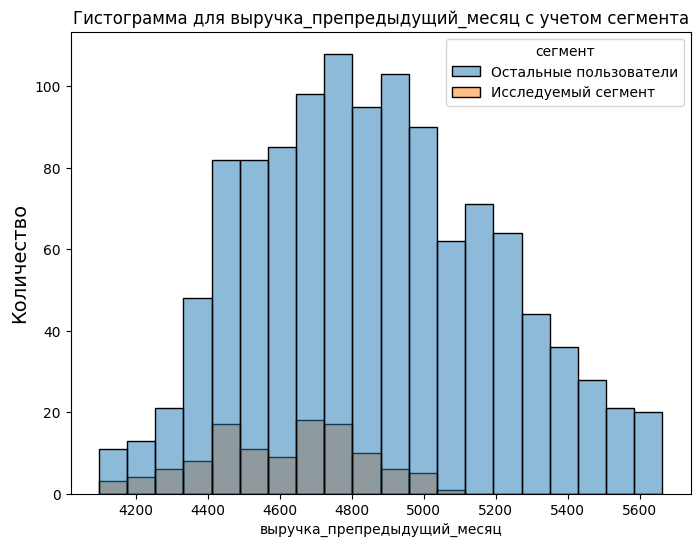

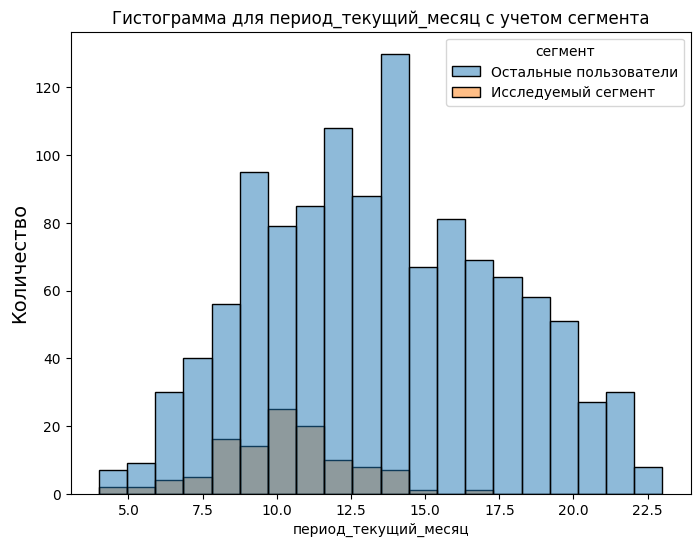

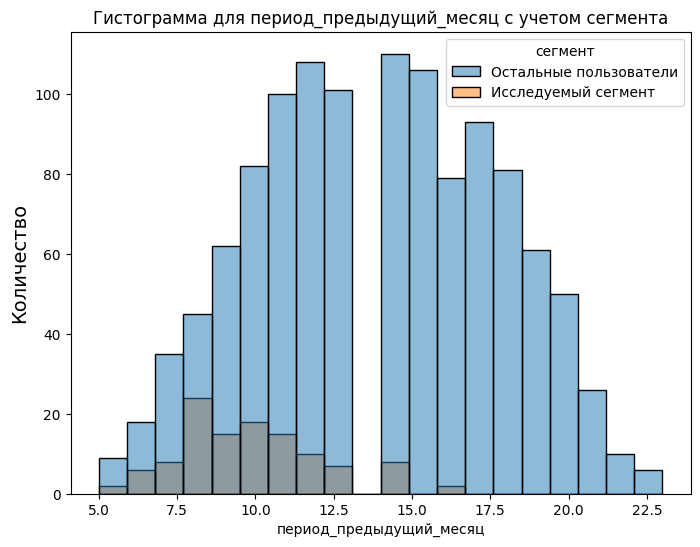

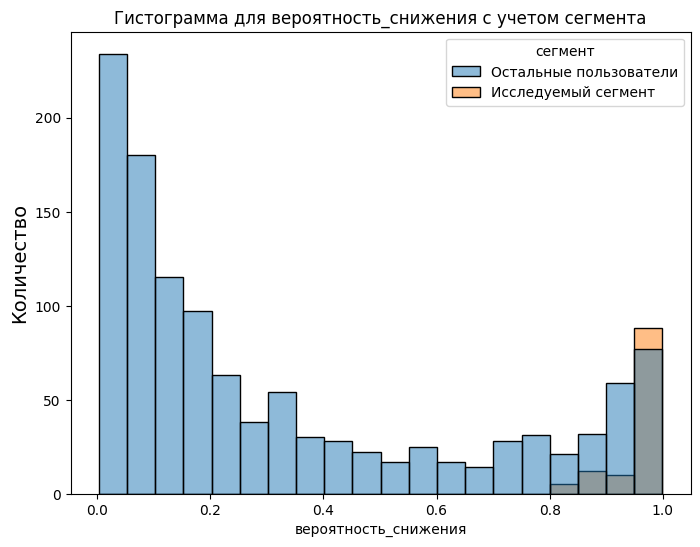

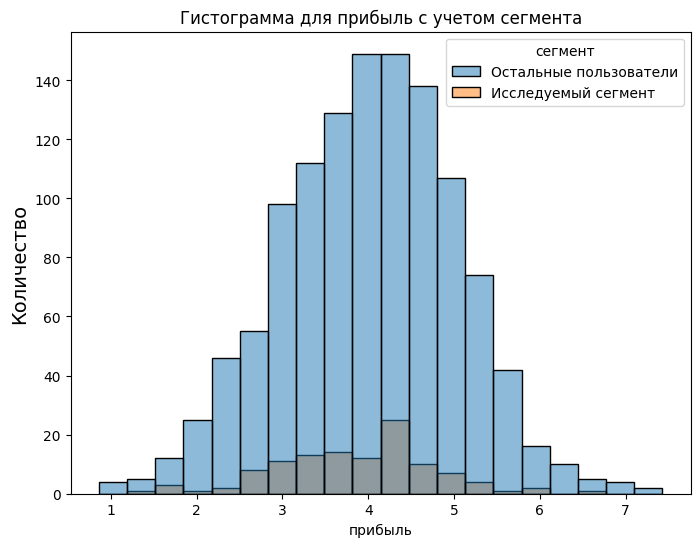

In [70]:
num_columns = list(df_full.select_dtypes(include='number').columns)
target = 'сегмент'
df = df_full

# Перебираем каждый числовой столбец и строим гистограмму
for col in num_columns:
    histogram(df, col, target)
    plt.title(f'Гистограмма для {col} с учетом сегмента')
    plt.show()  # выводит график для каждого столбца по очереди

Можно заметить, что с большинством покупателей из исследуемого сегмента потеряна маркетинговая коммуникация, на их долю последние два месяца приходится мало рассылок и звонков. Так же данный сегмент в основном просматривает мало категорий за один визит, мало страниц и проводят мало времени на сайте - они очень целенаправленно покупают. При этом пользователи из иследуемого сегмента в среднем оставляют неоплаченными в корзине больше товаров.

In [71]:
# визуализирую категориальные признаки df_market_file
plot_categorical_features( df_full[df_full['сегмент'] == 'Исследуемый сегмент'])

Скорее всего в этой категории много молодых мам, поскольку их интересуют товары для детей, домашний текстиль и косметика

Предложения для увеличения прибыли от покупателей в исследуемой категории:
- Увеличить количество рассылок со скидками;
- Обновлять информацию о скидках на главной странице;
- Акцентировать внимание на скидки в категориях товары для детей, домашний текстиль и косметика

Отдельно стоит отметить необходимость собирать данные по полу и возрасту покупателей, можно преподнести это под соусом "акция ко дню рождения"

**Выводы**

Во время сегменации было замечено, что пользователи, которые часто покупают по скидке чаще всего имеют высокую вероятность снижения активности. Для исследования была выбрана эта группа.

Можно заметить, что с большинством покупателей из исследуемого сегмента потеряна маркетинговая коммуникация, на их долю последние два месяца приходится мало рассылок и звонков. Так же данный сегмент в основном просматривает мало категорий за один визит, мало страниц и проводят мало времени на сайте - они очень целенаправленно покупают. При этом пользователи из иследуемого сегмента в среднем оставляют неоплаченными в корзине больше товаров.
Скорее всего в этой категории много молодых мам, поскольку их интересуют товары для детей, домашний текстиль и косметика.

Предложения для увеличения прибыли от покупателей в исследуемой категории:
- Увеличить количество рассылок со скидками;
- Обновлять информацию о скидках на главной странице;
- Акцентировать внимание на скидки в категориях товары для детей, домашний текстиль и косметика

Отдельно стоит отметить необходимость собирать данные по полу и возрасту покупателей, можно преподнести это под соусом "акция ко дню рождения"

## Общий вывод

Целью данного исследования было создание модели, способной прогнозировать снижение покупательской активности пользователей интернет-магазина "В один клик". Кроме того, важно было провести анализ выбранного сегмента пользователей.

**1. Анализ информации о данных**

1. В данных df_market_file 1300 строк. Пропуски отсутствуют. Названия некоторых столбцов содержат пробелы, что нужно будет исправить в дальнейшем
2. В данных df_market_money 3900 строк. Пропуски отсутствуют.
3. В данных df_market_time 2600 строк. Пропуски отсутствуют. В периоде есть опечатки, нужно будет исправить
4. В данных df_market_time 1300 строк. Пропуски отсутствуют


**2. Предобработка данных**

В ходе предобработки данных в датафреймах сделаны следующие преобразования:

1. Названия столбцов во всех датасетах приведены к единому формату
2. В столбцах тип_сервиса и период значения приведены к единому образцу

**3. Исследовательский анализ данных**

1. В df_market_money один выброс был заменен на медианное занчение.
2. Трое из 1300 покупателей не были активны в течение трех месяцев. Поэтому данные по ним исключены из анализа.
3. Выручка за последние три месяца примерно одинаковая
4. Большинство покупателей не ориентируются на скидки. Но часть клиентов отлеживают скидки. Поэтому подготовке данных для модели нужно превратить колонку акционные_покупки в категоральный признак.
5. Возможно, стоит поработать над стабильностью работы сайта. В среднем 4 разаза визит возникает ошибка сервиса.
6. Видно дисбаланс значений в целевом признаке, это нужно будет учесть в модели
7. Большинство клиентов (71,1%) пользуются типом сервиса стандарт
8. Самымой популярной категорией являются товары для детей, наименее популярной - кухонная посуда
9. Половина покупателей проводят на сайте от 10 до 16 минут.

**4. Объединение таблиц**

После объединения таблиц все данные находятся в одном датасете

**5. Корреляционный анализ признаков**

Целевой признак, связанный с покупательской активностью, имеет корреляцию с количеством страниц, которые клиенты просматривают за один визит, а также с временем, проведённым в предыдущем и текущем месяце. Из всех признаков наблюдается лишь одна относительно сильная корреляция между выручкой за предыдущий месяц и текущим месяцем, однако коэффициент корреляции составляет менее 0.9, что означает, что нет необходимости удалять эти признаки.

**6. Использование пайплайнов**

В результате анализа различных моделей с использованием пайплайнов наилучшей моделью оказалась линейная регрессия. Она обладает следующими характеристиками: значение параметра C равно 4, что указывает на умеренную регуляризацию — высокий параметр C позволяет модели лучше адаптироваться к данным, что в данном случае свидетельствует о относительно слабой регуляризации. Параметр penalty установлен на 'l1', что подразумевает использование L1-регуляризации, которая добавляет штраф за абсолютные значения коэффициентов модели во время процесса обучения. Это способствует отбору значимых признаков, приводя к тому, что менее важные параметры могут быть обнулены. Также фиксирован параметр random_state равным 42, что служит простой константой для обеспечения воспроизводимости результатов. Алгоритм оптимизации выбранный для обучения модели — 'liblinear', который хорошо подходит для задач двоичной классификации и эффективно справляется с средними и крупными наборами данных. Значение ROC AUC составило 0.92, что демонстрирует достаточно высокий уровень точности модели.

**7. Анализ важности признаков**

Для итоговой модели которую мы отобрали наиболее важными признаками является:
- доля акционных покупок;
- среднее кол-во просмотренных категорий за визит;
- проведенное в предыдущем и в этом месяце время;
- кол-во неоплаченных товаров в корзине за квартал.

Наименее важны оказались следующие признаки:
- выручка за текущий и предыдущий месяцы;
- популярные категории (за исключением бытовой техники и техники для красоты;
- разрешение на отправку рекламынх рассылок;
- тип сервиса;
- ошибки сервиса;
- длительность.

При принятии бизнес-решений важно учитывать поведение клиентов на сайте. Следует сосредоточиться на увеличении их вовлеченности, что включает в себя изучение времени прокрутки страниц и эффективность презентации новых категорий товаров. Организация скидок также может способствовать повышению интереса и активности пользователей.

**8. Сегментация покупателей**

Во время сегменации было замечено, что пользователи, которые часто покупают по скидке чаще всего имеют высокую вероятность снижения активности. Для исследования была выбрана эта группа.

Можно заметить, что с большинством покупателей из исследуемого сегмента потеряна маркетинговая коммуникация, на их долю последние два месяца приходится мало рассылок и звонков. Так же данный сегмент в основном просматривает мало категорий за один визит, мало страниц и проводят мало времени на сайте - они очень целенаправленно покупают. При этом пользователи из иследуемого сегмента в среднем оставляют неоплаченными в корзине больше товаров.
Скорее всего в этой категории много молодых мам, поскольку их интересуют товары для детей, домашний текстиль и косметика.


**Заключение**

Предложения для увеличения прибыли от покупателей:
- Увеличить количество рассылок со скидками;
- Обновлять информацию о скидках на главной странице;
- Акцентировать внимание на скидки в категориях товары для детей, домашний текстиль и косметика

Отдельно стоит отметить необходимость собирать данные по полу и возрасту покупателей.

## Ссылка на репозиторий GitHub

**Репозиторий проекта:** https://github.com/thatwh0came/supervised_learning_project
